# twixtools: Recon code

In [1]:
%matplotlib inline
import twixtools
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import torch
import json
from mirtorch_pkg import NuSense_om
from torchkbnufft import calc_density_compensation_function
import Nufftbindings.nufftbindings.kbnufft as kbnufft

main_dir = '/Users/Riccardo_1/Desktop/EPFL/MRI/MR_Trajectory_Fit/MRSI_trajs/data/4Riccardo'
file_name = 'meas_MID00212_FID11351_ad_edMrsi_waterRef_20260520_02337.dat'
dcfnet_path = f'/Users/Riccardo_1/Desktop/EPFL/MRI/MR_Trajectory_Fit/trained_models/dcfnet_512_unet_trained_with_E.pt'
rosette_path = f'/Users/Riccardo_1/Desktop/EPFL/MRI/MR_Trajectory_Fit/MRSI_trajs/2026-05-20_23-37_fixed_pns105/kspace_traj_2026-05-20_23-37.json'
saving_folder = '/Users/Riccardo_1/Desktop/EPFL/MRI/MR_Trajectory_Fit/MRSI_trajs/2026-05-20_23-37_fixed_pns105/reconstructions'
os.makedirs(saving_folder, exist_ok=True)

folder_modules= os.path.abspath('/Users/Riccardo_1/Desktop/EPFL/MRI/MR_Trajectory_Fit') 
if folder_modules not in sys.path:
    sys.path.append(folder_modules)

# from utils_3 import ImageRecon
from params import *
from models import UNet1D

## `read_twix`: Direct access to the raw data

`read_twix` provides low-level access to the Siemens MRI raw data, on a block-by-block ("mdb") level.

    Parameters
    ----------
    infile : filename or measurement id of .dat file
    include_scans: list of scan numbers or None, optional
        By default, all scans in a multi-raid file are parsed.
    parse_prot : bool, optional
        By default, the protocol information is parsed.
        (this is also highly recommended)
    parse_data: bool, optional
        Set to False to parse only protocol information.
    parse_geometry: bool, optional
        Set to False to skip creation of transformation matrix from data
        coordinates to physical coordinates.
    verbose: bool, optional
        Switch progress and other messages on or off.
    keep_acqend : bool, optional
        By default, acqend blocks are not included in the mdb list.
        This block is helpful for twix writing, but unnecessary otherwise.
    keep_syncdata : bool, optional
        By default, syncdata blocks are included in the mdb list.
        These blocks may include physio. (PMU) or trajectory information.

    Returns
    -------
    out: list of twix scan(s)
        The twix scans themselves consist of a dict with these elements:
            - hdr: dict of parsed ascconv and XProtocol header information
            - hdr_str: header bytearray (used by write_twix)
            - mdb: list of measurement data blocks -- here is the MRI data
              use `help(twixtools.mdb.Mdb)` for more information
            - geometry: dict containing geometry information about the scan
              use `help(twixtools.geometry)` for more information

In [2]:
# parse the twix file
twix = twixtools.read_twix(os.path.join(main_dir, file_name))

# twix is a list of measurements:
print('\nnumber of separate scans (multi-raid):', len(twix))
# sort all 'imaging' mdbs into a k-space array
image_mdbs = [mdb for mdb in twix[-1]['mdb'] if mdb.is_image_scan()]
print(f"Number of petals: {len(image_mdbs)}") 
print(f"Shape of each petal: {image_mdbs[0].data.shape}")

Software version: VD/VE (!?)

Scan  0


100%|██████████| 32.3M/32.3M [00:00<00:00, 1.26GB/s]


Scan  1


100%|██████████| 641M/641M [00:00<00:00, 1.59GB/s]


number of separate scans (multi-raid): 2
Number of petals: 80
Shape of each petal: (32, 32704)


## Correct shape for the k-space input

In [3]:
N_PETALS = 80
N_COILS = 32
N_POINTS_PER_PETAL = 100
N_REPEATS = 325

data_raw = np.array([mdb.data for mdb in image_mdbs])
print(f"Raw stacked shape: {data_raw.shape}") 
# Output: (80, 32, 32704)

# 42 extra points at the beginning are not valid
data_valid = data_raw[:, :, 42:]
print(f"Shape after discarding initial 42 points: {data_valid.shape}")

# We discard last points to get 32500 (100 x 325) valid points per petal
data_valid = data_valid[:, :, :32500]
print(f"Final shape: {data_valid.shape}")

data = data_valid.reshape(N_PETALS, N_COILS, N_REPEATS, N_POINTS_PER_PETAL)
data_t0 = data[:, :, 0, :]  # (petals, coils, points)
data_flat = data_t0.transpose(1, 0, 2).reshape(N_COILS, -1)

print("flat:", data_flat.shape)

sampled_tensor = torch.tensor(data_flat, dtype=torch.complex64)  # shape: (32, 8000)
print(f"sampled tensor shape: {sampled_tensor.shape}")

Raw stacked shape: (80, 32, 32704)
Shape after discarding initial 42 points: (80, 32, 32662)
Final shape: (80, 32, 32500)
flat: (32, 8000)
sampled tensor shape: torch.Size([32, 8000])


## Reconstruction

### Rosette trajectory

kxx orig shape: (80, 100), kyy orig shape: (80, 100)
kxx resort shape: (80, 100), kyy resort shape: (80, 100)
rosette orig tensor shape: torch.Size([8000, 2])
rosette resort tensor shape: torch.Size([8000, 2])


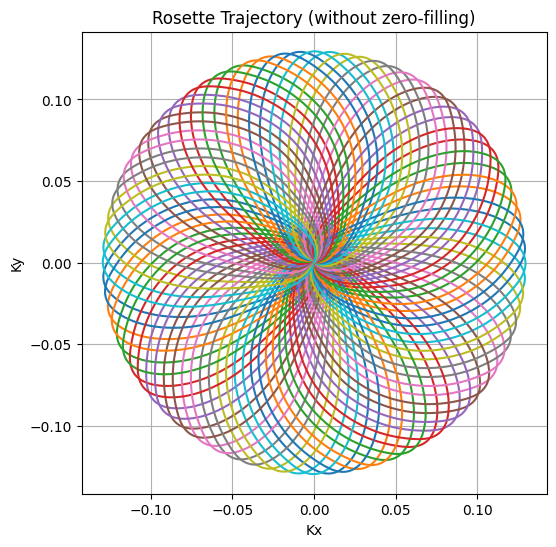

In [4]:
with open(rosette_path, 'r') as f:
    traj_dict = json.load(f)

petal_order = np.r_[np.arange(0, N_PETALS, 2), np.arange(1, N_PETALS, 2)]
kx = np.array(traj_dict['k_space']['Kx'])
ky = np.array(traj_dict['k_space']['Ky']) 

kxx_resort = kx[petal_order, :] # shape: (80, 100)
kyy_resort = ky[petal_order, :] # shape: (80, 100)
kxx_orig = kx  # shape: (80, 100)
kyy_orig = ky  # shape: (80, 100)

kxx_optim = kxx_resort.copy()
kyy_optim = kyy_resort.copy()

print(f"kxx orig shape: {kxx_orig.shape}, kyy orig shape: {kyy_orig.shape}")
print(f"kxx resort shape: {kxx_resort.shape}, kyy resort shape: {kyy_resort.shape}")

rosette_orig_tensor = torch.tensor(np.stack((kxx_orig, kyy_orig), axis=-1), dtype=torch.float32)  # shape: (80, 100, 2)
rosette_resort_tensor = torch.tensor(np.stack((kxx_resort, kyy_resort), axis=-1), dtype=torch.float32)  # shape: (80, 100, 2)
rosette_orig_tensor = rosette_orig_tensor.reshape(-1, 2)
rosette_resort_tensor = rosette_resort_tensor.reshape(-1, 2)
print(f"rosette orig tensor shape: {rosette_orig_tensor.shape}")
print(f"rosette resort tensor shape: {rosette_resort_tensor.shape}")

plt.figure(figsize=[6,6])
for i in range(80):
    plt.plot(kxx_resort[i], kyy_resort[i])
plt.title('Rosette Trajectory (without zero-filling)')
plt.xlabel('Kx')
plt.ylabel('Ky')
plt.axis('equal')
plt.grid()
plt.show()

### Nyquist check

Distances shape: (8000, 2), Indices shape: (8000, 2)
First 5 distances:
[[0.00000000e+00 5.22399258e-10]
 [0.00000000e+00 9.59439487e-05]
 [0.00000000e+00 2.94021887e-04]
 [0.00000000e+00 4.30177617e-04]
 [0.00000000e+00 5.62362150e-04]]


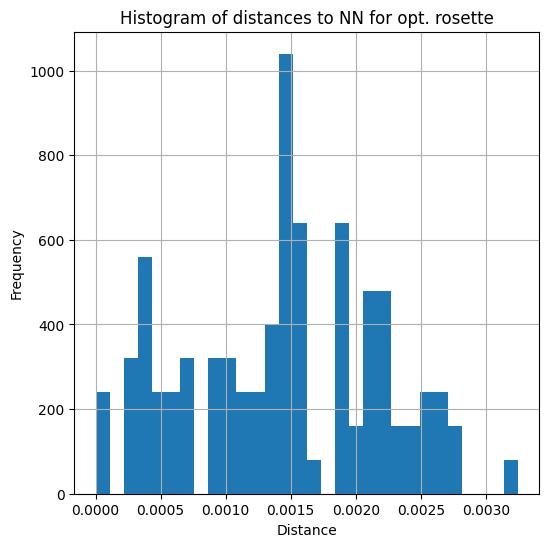

In [5]:
from sklearn.neighbors import NearestNeighbors

X = np.column_stack((kxx_resort.ravel(), kyy_resort.ravel()))
nbrs = NearestNeighbors(n_neighbors=2, algorithm='ball_tree',metric='euclidean').fit(X)
distances, indices = nbrs.kneighbors(X)

print(f"Distances shape: {distances.shape}, Indices shape: {indices.shape}")
print(f"First 5 distances:\n{distances[:5]}") # this means that the first neighbour is the point itself (distance 0), and the second is the nearest other point.

plt.figure(figsize=[6,6])
plt.hist(distances[:, 1], bins=30)  # distances to the nearest neighbor (excluding itself)
plt.title('Histogram of distances to NN for opt. rosette')
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.grid()

### take points until kmax (included)

Max distance is 0.12942431945415123 and the corresponding index is 52


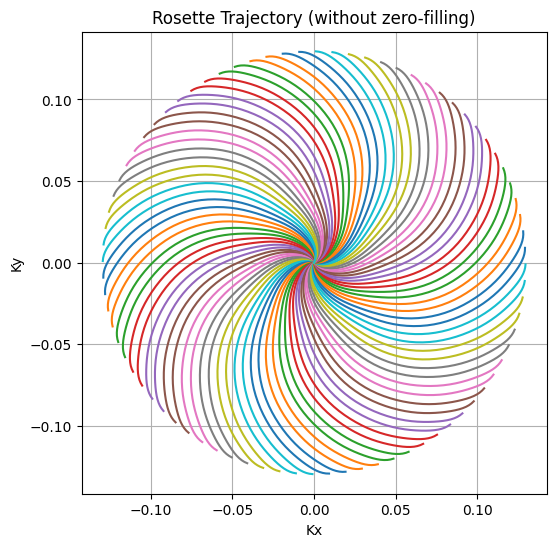

In [6]:
# take points until kmax
# kxx_resort and kyy_resort have shape (80, 100)

x0, y0 = kxx_resort[0, 0], kyy_resort[0, 0] # first point of the first petal
distances = np.sqrt((kxx_resort[0, :] - x0)**2 + (kyy_resort[0, :] - y0)**2) #distances over the first petal
max_idx = np.argmax(distances)
max_dist = distances[max_idx]

print(f"Max distance is {max_dist} and the corresponding index is {max_idx}")

#take point until that point for every petal 
mask = np.zeros_like(kxx_resort, dtype=bool)
for i in range(80):
    mask[i, :max_idx+1] = True  

#plot rosette trajectory with the mask applied
plt.figure(figsize=[6,6])
for i in range(80):
    plt.plot(kxx_resort[i][mask[i]], kyy_resort[i][mask[i]])
plt.title('Rosette Trajectory (without zero-filling)')
plt.xlabel('Kx')
plt.ylabel('Ky')
plt.axis('equal')
plt.grid()
plt.show()

### Image

In [7]:

# Shape helpers: no zero-filling.
# These functions only coerce rosettes/samples/masks to the shapes expected by the recon code.

def shape_rosette_for_recon(rosette, device=None, dtype=torch.float32):
    """
    Return trajectory as (N, 2), without adding any synthetic k-space points.
    Accepts either (N, 2) or (2, N).
    """
    rosette = torch.as_tensor(rosette, dtype=dtype, device=device).squeeze()
    if rosette.ndim != 2:
        raise ValueError(f"Expected a 2D trajectory tensor, got shape {tuple(rosette.shape)}")
    if rosette.shape[-1] == 2:
        return rosette.contiguous()
    if rosette.shape[0] == 2:
        return rosette.T.contiguous()
    raise ValueError(f"Trajectory must have shape (N, 2) or (2, N), got {tuple(rosette.shape)}")


def shape_samples_for_recon(sampled, device=None):
    """
    Return samples as (N,), without appending zero-valued samples.
    """
    sampled = torch.as_tensor(sampled, device=device).squeeze()
    if sampled.ndim != 1:
        raise ValueError(f"Expected 1D samples, got shape {tuple(sampled.shape)}")
    return sampled.contiguous()


def shape_mask_for_recon(mask, device=None):
    """
    Return mask as flattened bool tensor, without appending zero-fill mask entries.
    """
    return torch.as_tensor(mask, dtype=torch.bool, device=device).reshape(-1).contiguous()


In [8]:

from torchkbnufft import KbNufft


def get_device():
    import torch

    if torch.cuda.is_available():
        return torch.device("cuda")
    # Disable MPS due to memory constraints - use CPU instead
    # elif torch.backends.mps.is_available():
    #     return torch.device("mps")
    else:
        return torch.device("cpu")


class ImageRecon:
    """
    Reconstruction with two independent image sizes:
      - dcf_img_size: fixed at 512 because DCFNet was trained at 512 x 512 and DCF normalization should use that grid.
      - recon_img_size: trajectory-derived matrix size, e.g. 58 x 58, used only for the final adjoint reconstruction.

    No zero-filling is added. Helper functions only coerce tensors to the correct shape.
    """

    def __init__(self, params, kmax_img, dcfnet_path, recon_img_size=None, dcf_img_size=512, recon_kmax_img=None):
        self.device = get_device()
        # Keep two independent trajectory scalings:
        #   - dcf_kmax_img: 512-grid scaling used by DCFNet and DCF normalization.
        #   - recon_kmax_img: final reconstruction-grid scaling, e.g. 58 / (2 * FoV).
        self.dcf_kmax_img = float(kmax_img)
        self.dcf_img_size = int(dcf_img_size)
        self.recon_img_size = int(recon_img_size if recon_img_size is not None else params["img_size"])
        self.recon_kmax_img = float(
            recon_kmax_img if recon_kmax_img is not None else self.recon_img_size / (2 * params["FoV"])
        )
        self.img_size = self.recon_img_size  # kept for backwards-compatible plotting/printing
        self.timesteps = params["timesteps"]
        self.n_petals = params["n_petals"]

        dcfdict, kernel_size, features = torch.load(dcfnet_path, map_location=self.device)
        self.dcfnet = UNet1D(in_channels=2, out_channels=1, features=features, kernel_size=kernel_size)
        self.dcfnet.load_state_dict(dcfdict)
        self.dcfnet.to(self.device)
        self.dcfnet.eval()

    @staticmethod
    def _im_tuple(img_size):
        img_size = int(img_size)
        return (img_size, img_size)

    def _scale_traj_dcf(self, rosette):
        # 512-grid scaling for DCFNet and DCF normalization.
        # This is kept fixed because the DCF network was trained on 512 x 512 images.
        return shape_rosette_for_recon(rosette, device=self.device) / self.dcf_kmax_img * torch.pi

    def _scale_traj_recon(self, rosette):
        # Reconstruction-grid scaling for the final NUFFT adjoint, e.g. 58 x 58.
        # This prevents the 58 x 58 reconstruction from being scaled as if it were 512 x 512.
        return shape_rosette_for_recon(rosette, device=self.device) / self.recon_kmax_img * torch.pi

    def _sort_dcf_from_orig_to_sorted(self, dcf):
        """DCF is predicted/computed in original petal order; return it in petal_order sorted order."""
        n_points = dcf.shape[-1]
        if n_points % self.n_petals != 0:
            raise ValueError(
                f"Cannot reorder DCF: {n_points} points is not divisible by n_petals={self.n_petals}. "
                "Use a direct masked trajectory with mask=None if petals no longer have equal length."
            )
        n_points_per_petal = n_points // self.n_petals
        return dcf.view(1, self.n_petals, n_points_per_petal)[:, petal_order, :].reshape(1, 1, -1)

    def reconstruct_img_mirtorch(self, rosette_orig, rosette_sorted, sampled, mask=None):
        rosette_orig_dcf = self._scale_traj_dcf(rosette_orig).T.contiguous()          # (2, N)
        rosette_sorted_recon = self._scale_traj_recon(rosette_sorted).T.contiguous()  # (2, N)
        sampled = shape_samples_for_recon(sampled, device=self.device).reshape(1, 1, -1)

        if sampled.shape[-1] != rosette_sorted_recon.shape[-1]:
            raise ValueError(
                f"sampled has {sampled.shape[-1]} points but rosette_sorted has {rosette_sorted_recon.shape[-1]} points"
            )

        # Operator 1: 512 x 512 operator for DCF computation and normalization.
        s0_dcf = torch.ones(1, 1, self.dcf_img_size, self.dcf_img_size, device=self.device) + 0j
        Nop_dcf_orig = NuSense_om(s0_dcf, rosette_orig_dcf.reshape(1, 2, -1), norm=None)

        dcf = calc_density_compensation_function(
            rosette_orig_dcf,
            self._im_tuple(self.dcf_img_size),
        ).view(1, 1, -1) + 0j
        dcf = self.normalize_dcf_mirtorch(dcf, Nop_dcf_orig, self.dcf_img_size)
        dcf_sorted = self._sort_dcf_from_orig_to_sorted(dcf)

        # Operator 2: trajectory-derived matrix size for final reconstruction.
        s0_recon = torch.ones(1, 1, self.recon_img_size, self.recon_img_size, device=self.device) + 0j

        if mask is None:
            Nop_recon = NuSense_om(s0_recon, rosette_sorted_recon.reshape(1, 2, -1), norm=None)
            I0 = Nop_recon.H * (dcf_sorted * sampled)
        else:
            mask = shape_mask_for_recon(mask, device=self.device)
            rosette_masked = rosette_sorted_recon[:, mask].reshape(1, 2, -1)
            Nop_recon = NuSense_om(s0_recon, rosette_masked, norm=None)
            I0 = Nop_recon.H * (dcf_sorted[..., mask] * sampled[..., mask])

        I0 = torch.flip(torch.rot90(I0.abs(), k=1, dims=(2, 3)), dims=[2]).squeeze()
        return dcf_sorted, I0

    def reconstruct_img_dcfnet(self, rosette_orig, rosette_sorted, sampled, mask=None):
        rosette_orig_dcf = self._scale_traj_dcf(rosette_orig)          # (N, 2)
        rosette_sorted_recon = self._scale_traj_recon(rosette_sorted)  # (N, 2)
        sampled = shape_samples_for_recon(sampled, device=self.device).reshape(1, 1, -1)

        if sampled.shape[-1] != rosette_sorted_recon.shape[0]:
            raise ValueError(
                f"sampled has {sampled.shape[-1]} points but rosette_sorted has {rosette_sorted_recon.shape[0]} points"
            )

        # Operator 1: 512 x 512 operator for DCFNet prediction normalization.
        with torch.no_grad():
            dcf = self.dcfnet(rosette_orig_dcf.permute(1, 0).unsqueeze(0)).squeeze() + 0j
        dcf = dcf.view(1, 1, -1)

        kbnufft.nufft.set_dims(
            rosette_orig_dcf.shape[0],
            self._im_tuple(self.dcf_img_size),
            device=self.device,
            Nb=1,
        )
        print(f"Setting kbnufft operator for DCF normalization with {rosette_orig_dcf.shape[0]} points and image size {self._im_tuple(self.dcf_img_size)}")
        kbnufft.nufft.precompute(rosette_orig_dcf)
        dcf = self.normalize_dcf(dcf, rosette_orig_dcf, self._im_tuple(self.dcf_img_size))
        dcf_sorted = self._sort_dcf_from_orig_to_sorted(dcf)

        # Operator 2: trajectory-derived matrix size for final reconstruction.
        if mask is None:
            kbnufft.nufft.set_dims(
                rosette_sorted_recon.shape[0],
                self._im_tuple(self.recon_img_size),
                device=self.device,
                Nb=1,
            )
            print(f"Setting kbnufft operator for final recon with {rosette_sorted_recon.shape[0]} points and image size {self._im_tuple(self.recon_img_size)}")
            kbnufft.nufft.precompute(rosette_sorted_recon)
            I0 = kbnufft.adjoint(rosette_sorted_recon, (sampled * dcf_sorted).squeeze(0)).unsqueeze(0)
        else:
            mask = shape_mask_for_recon(mask, device=self.device)
            rosette_masked = rosette_sorted_recon[mask, ...]
            sampled_masked = sampled[..., mask]
            dcf_masked = dcf_sorted[..., mask]

            kbnufft.nufft.set_dims(
                rosette_masked.shape[0],
                self._im_tuple(self.recon_img_size),
                device=self.device,
                Nb=1,
            )
            print(f"Setting kbnufft operator for masked recon with {rosette_masked.shape[0]} points and image size {self._im_tuple(self.recon_img_size)}")
            kbnufft.nufft.precompute(rosette_masked)
            I0 = kbnufft.adjoint(rosette_masked, (sampled_masked * dcf_masked).squeeze(0)).unsqueeze(0)

        I0 = torch.flip(torch.rot90(I0.abs(), k=1, dims=(2, 3)), dims=[2]).squeeze()
        return dcf_sorted, I0

    def normalize_dcf(self, dcf, ktraj, im_size):
        # Called only after kbnufft.nufft has been set/precomputed with the 512 DCF operator.
        x = torch.ones(1, *im_size, device=dcf.device) + 0j
        k = kbnufft.forward(ktraj, x)
        x_rec = kbnufft.adjoint(ktraj, k * dcf.squeeze(0)).abs()
        scale = x_rec.sum() / (x_rec**2).sum()
        return dcf * scale

    def normalize_dcf_mirtorch(self, dcf, Nop, img_size):
        x = torch.ones(1, 1, int(img_size), int(img_size), device=dcf.device) + 0j
        k = Nop * x
        x_rec = Nop.H * (dcf * k)
        scale = x_rec.sum() / (x_rec**2).sum()
        return dcf * scale


### new image resolution

In [9]:

print(f"Max k-space value in trajectory: {torch.abs(rosette_resort_tensor).max():.4f}")
new_kmax_img = float(torch.abs(rosette_resort_tensor).max())
new_resolution = int(np.round(new_kmax_img * 2 * params["FoV"]))
print(f"New reconstruction kmax_img: {new_kmax_img:.4f}")
print(f"Nominal reconstruction matrix: {new_resolution:.0f} x {new_resolution:.0f}")
new_resolution_mm = params['FoV'] / new_resolution
print(f"Nominal in-plane resolution: {new_resolution_mm:.2f} x {new_resolution_mm:.2f} mm2")

# DCF stays on the 512 x 512 grid used during DCFNet training.
# Final image reconstruction uses the trajectory-derived matrix size, e.g. 58 x 58.
recon = ImageRecon(
    params,
    kmax_img,
    dcfnet_path,
    recon_img_size=new_resolution,
    dcf_img_size=512,
    recon_kmax_img=new_kmax_img,
)

rosette_orig_recon = shape_rosette_for_recon(rosette_orig_tensor, device=recon.device)
rosette_resort_recon = shape_rosette_for_recon(rosette_resort_tensor, device=recon.device)
mask_recon = shape_mask_for_recon(mask, device=recon.device)

print("DCF image size:", recon.dcf_img_size)
print("DCF kmax_img:", recon.dcf_kmax_img)
print("Reconstruction image size:", recon.recon_img_size)
print("Reconstruction kmax_img:", recon.recon_kmax_img)
print("rosette_orig_recon:", rosette_orig_recon.shape)
print("rosette_resort_recon:", rosette_resort_recon.shape)
print("mask_recon:", mask_recon.shape)


Max k-space value in trajectory: 0.1294
New reconstruction kmax_img: 0.1294
Nominal reconstruction matrix: 58 x 58
Nominal in-plane resolution: 3.86 x 3.86 mm2
DCF image size: 512
DCF kmax_img: 1.1428571428571428
Reconstruction image size: 58
Reconstruction kmax_img: 0.12942013144493103
rosette_orig_recon: torch.Size([8000, 2])
rosette_resort_recon: torch.Size([8000, 2])
mask_recon: torch.Size([8000])


In [10]:
images_coils = []
for i in range(N_COILS):
    sampled_i = shape_samples_for_recon(sampled_tensor[i], device=recon.device)
    _, image_coil = recon.reconstruct_img_dcfnet(
        rosette_orig_recon,
        rosette_resort_recon,
        sampled_i,
        mask=mask_recon,
    )
    images_coils.append(image_coil.detach().cpu().numpy())

images_coils = np.array(images_coils)
image_rss_dcfnet_masked = np.sqrt(np.sum(np.abs(images_coils)**2, axis=0))

images_coils = []
for i in range(N_COILS):
    sampled_i = shape_samples_for_recon(sampled_tensor[i], device=recon.device)
    _, image_coil = recon.reconstruct_img_dcfnet(
        rosette_orig_recon,
        rosette_resort_recon,
        sampled_i,
        mask=None,
    )
    images_coils.append(image_coil.detach().cpu().numpy())

images_coils = np.array(images_coils)
image_rss_dcfnet = np.sqrt(np.sum(np.abs(images_coils)**2, axis=0))

images_coils = []
for i in range(N_COILS):
    sampled_i = shape_samples_for_recon(sampled_tensor[i], device=recon.device)
    _, image_coil = recon.reconstruct_img_mirtorch(
        rosette_orig_recon,
        rosette_resort_recon,
        sampled_i,
        mask=mask_recon,
    )
    images_coils.append(image_coil.detach().cpu().numpy())

images_coils = np.array(images_coils)
image_rss_mirtorch_masked = np.sqrt(np.sum(np.abs(images_coils)**2, axis=0))

images_coils = []
for i in range(N_COILS):
    sampled_i = shape_samples_for_recon(sampled_tensor[i], device=recon.device)
    _, image_coil = recon.reconstruct_img_mirtorch(
        rosette_orig_recon,
        rosette_resort_recon,
        sampled_i,
        mask=None,
    )
    images_coils.append(image_coil.detach().cpu().numpy())

images_coils = np.array(images_coils)
image_rss_mirtorch = np.sqrt(np.sum(np.abs(images_coils)**2, axis=0))

print(f"Max and min pixel value in DCFNet reconstruction: {image_rss_dcfnet_masked.max()}, {image_rss_dcfnet_masked.min()}")
print(f"Max and min pixel value in DCFNet reconstruction (unmasked): {image_rss_dcfnet.max()}, {image_rss_dcfnet.min()}")
print(f"Max and min pixel value in MIRTorch reconstruction: {image_rss_mirtorch_masked.max()}, {image_rss_mirtorch_masked.min()}")
print(f"Max and min pixel value in MIRTorch reconstruction (unmasked): {image_rss_mirtorch.max()}, {image_rss_mirtorch.min()}")

print("Output image shape:", image_rss_dcfnet.shape)
i_max = max(image_rss_dcfnet_masked.max(), image_rss_mirtorch_masked.max(), image_rss_dcfnet.max(), image_rss_mirtorch.max())


Setting kbnufft operator for DCF normalization with 8000 points and image size (512, 512)
Setting kbnufft operator for masked recon with 4240 points and image size (58, 58)


/Users/Riccardo_1/Desktop/EPFL/MRI/MR_Trajectory_Fit/venv/lib/python3.12/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4383.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Setting kbnufft operator for DCF normalization with 8000 points and image size (512, 512)
Setting kbnufft operator for masked recon with 4240 points and image size (58, 58)
Setting kbnufft operator for DCF normalization with 8000 points and image size (512, 512)
Setting kbnufft operator for masked recon with 4240 points and image size (58, 58)
Setting kbnufft operator for DCF normalization with 8000 points and image size (512, 512)
Setting kbnufft operator for masked recon with 4240 points and image size (58, 58)
Setting kbnufft operator for DCF normalization with 8000 points and image size (512, 512)
Setting kbnufft operator for masked recon with 4240 points and image size (58, 58)
Setting kbnufft operator for DCF normalization with 8000 points and image size (512, 512)
Setting kbnufft operator for masked recon with 4240 points and image size (58, 58)
Setting kbnufft operator for DCF normalization with 8000 points and image size (512, 512)
Setting kbnufft operator for masked recon wit

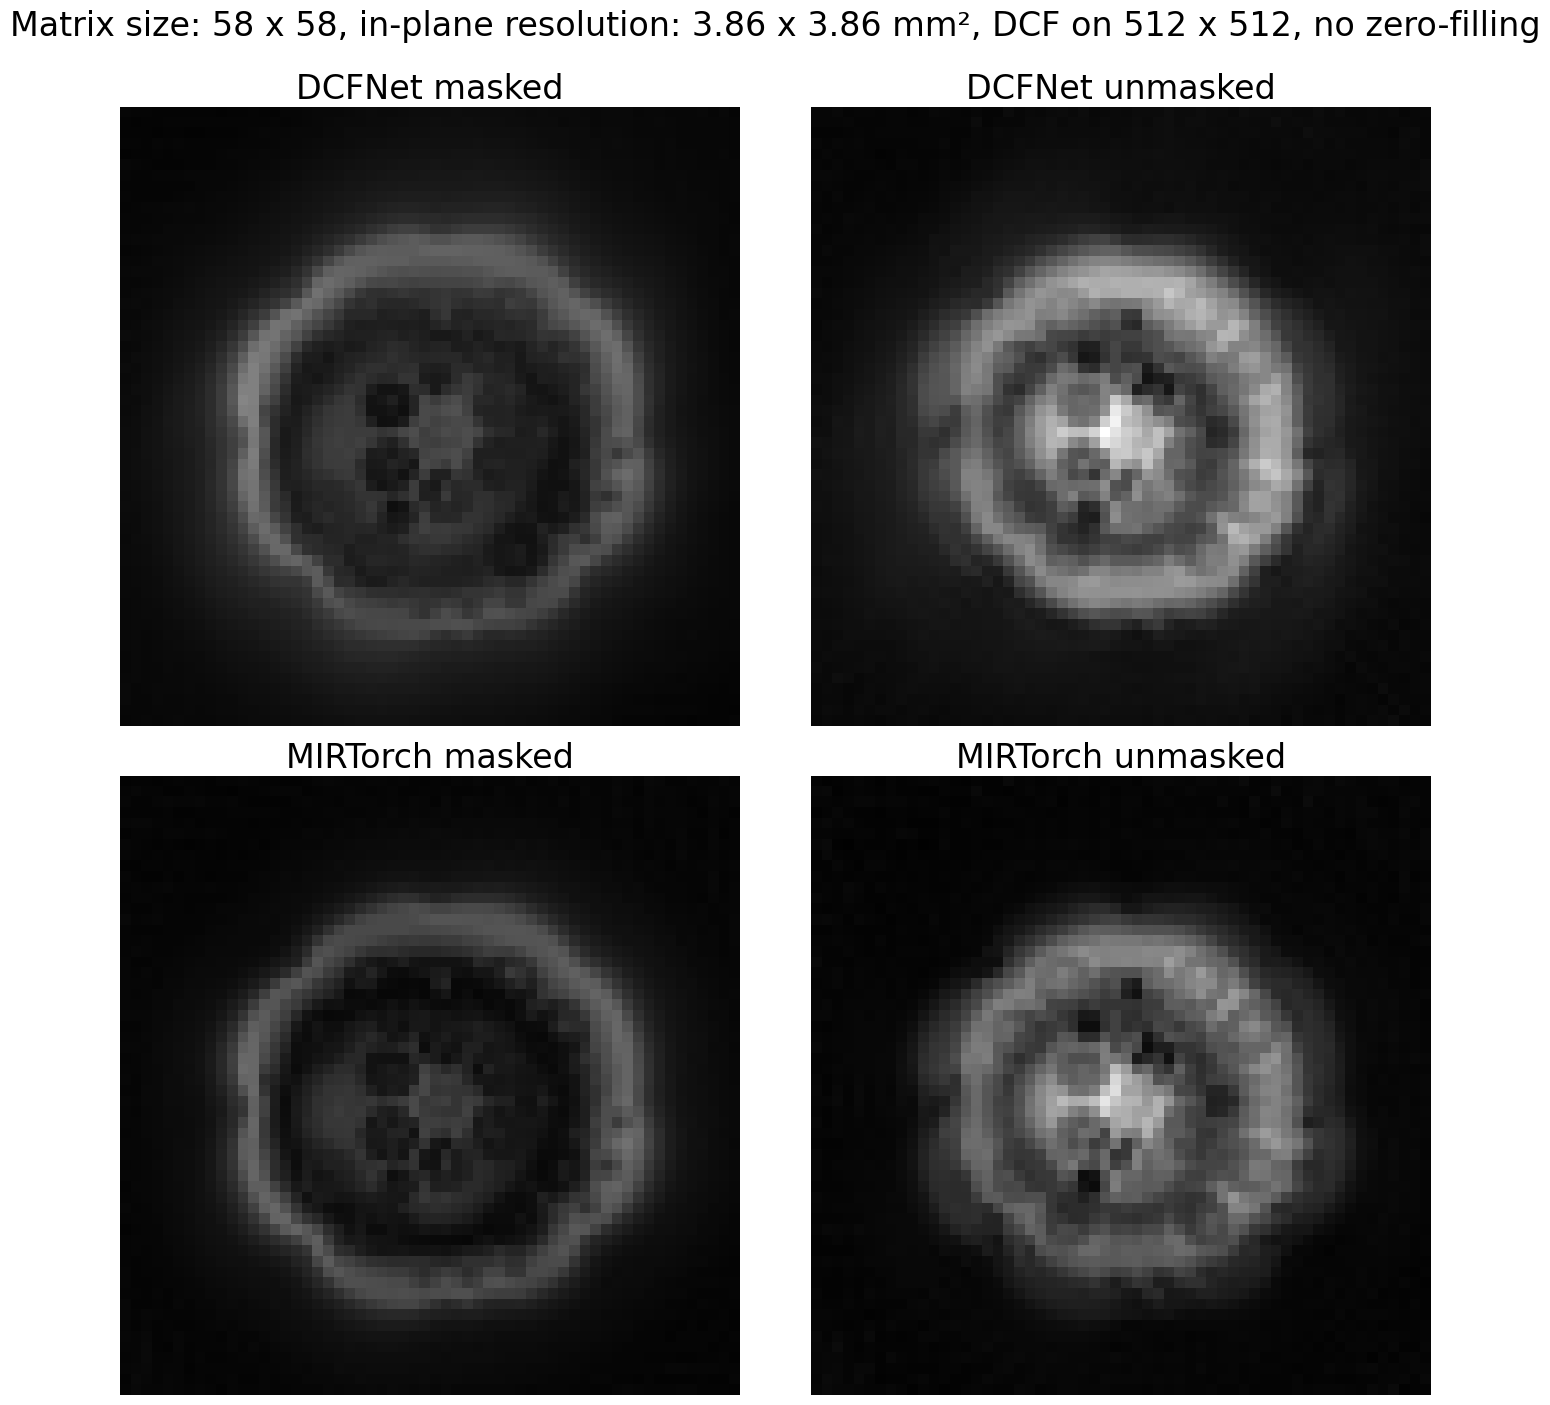

In [11]:
titles = [
    "DCFNet masked",
    "DCFNet unmasked",
    "MIRTorch masked",
    "MIRTorch unmasked",
]

images = [
    image_rss_dcfnet_masked,
    image_rss_dcfnet,
    image_rss_mirtorch_masked,
    image_rss_mirtorch,
]

plt.figure(figsize=(14, 14))

for idx, (img, title) in enumerate(zip(images, titles), start=1):
    plt.subplot(2, 2, idx)
    plt.imshow(np.abs(img), cmap="gray", vmin=0, vmax=i_max)
    plt.title(title, fontsize=24)
    plt.axis("off")

plt.suptitle(
    f"Matrix size: {new_resolution} x {new_resolution}, "
    f"in-plane resolution: {new_resolution_mm:.2f} x {new_resolution_mm:.2f} mm², "
    f"DCF on 512 x 512, no zero-filling",
    fontsize=24,
    y=1
)

plt.tight_layout()
plt.show()


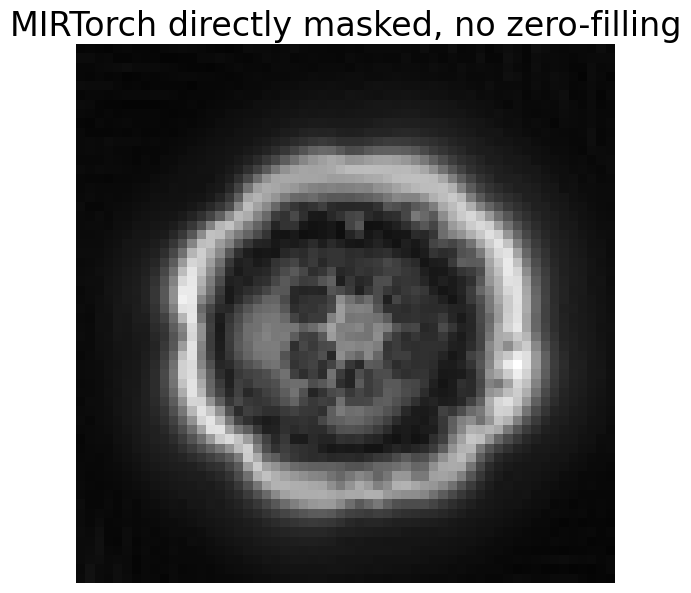

In [12]:
# Directly masked MIRTorch reconstruction, no zero-filling.
mask_resort = mask.astype(bool)

# Convert the resorted mask back to original petal order for rosette_orig.
mask_orig = np.zeros_like(mask_resort)
mask_orig[petal_order, :] = mask_resort

mask_resort_flat = mask_resort.reshape(-1)
mask_orig_flat = mask_orig.reshape(-1)

rosette_orig_masked = shape_rosette_for_recon(rosette_orig_tensor[mask_orig_flat], device=recon.device)
rosette_resort_masked = shape_rosette_for_recon(rosette_resort_tensor[mask_resort_flat], device=recon.device)

images_coils = []
for i in range(N_COILS):
    sampled_masked = shape_samples_for_recon(sampled_tensor[i][mask_resort_flat], device=recon.device)

    _, image_coil = recon.reconstruct_img_mirtorch(
        rosette_orig_masked,
        rosette_resort_masked,
        sampled_masked,
        mask=None,
    )

    images_coils.append(image_coil.detach().cpu().numpy())

images_coils = np.array(images_coils)
image_rss_mirtorch_direct_masked = np.sqrt(np.sum(np.abs(images_coils) ** 2, axis=0))

plt.figure(figsize=(7, 7))
plt.imshow(
    image_rss_mirtorch_direct_masked,
    cmap="gray",
    vmin=0,
    # vmax=i_max,
)
plt.title("MIRTorch directly masked, no zero-filling", size=24)
plt.axis("off")
plt.savefig(f"{saving_folder}/mirtorch_direct_masked_no_zf.png", bbox_inches="tight", pad_inches=0)
plt.show()


Setting kbnufft operator for DCF normalization with 4240 points and image size (512, 512)
Setting kbnufft operator for final recon with 4240 points and image size (58, 58)
Setting kbnufft operator for DCF normalization with 4240 points and image size (512, 512)
Setting kbnufft operator for final recon with 4240 points and image size (58, 58)
Setting kbnufft operator for DCF normalization with 4240 points and image size (512, 512)
Setting kbnufft operator for final recon with 4240 points and image size (58, 58)
Setting kbnufft operator for DCF normalization with 4240 points and image size (512, 512)
Setting kbnufft operator for final recon with 4240 points and image size (58, 58)
Setting kbnufft operator for DCF normalization with 4240 points and image size (512, 512)
Setting kbnufft operator for final recon with 4240 points and image size (58, 58)
Setting kbnufft operator for DCF normalization with 4240 points and image size (512, 512)
Setting kbnufft operator for final recon with 4240

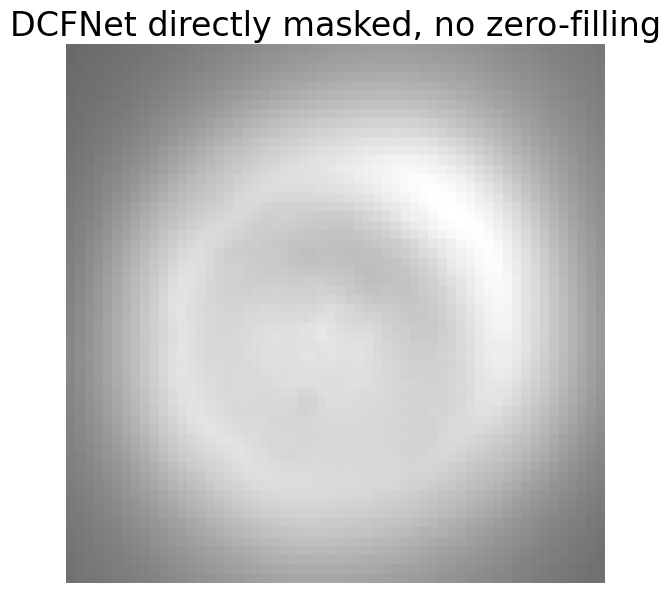

In [13]:

# Directly masked DCFNet reconstruction, no zero-filling.
mask_resort = mask.astype(bool)

# Convert the resorted mask back to original petal order for rosette_orig.
mask_orig = np.zeros_like(mask_resort)
mask_orig[petal_order, :] = mask_resort

mask_resort_flat = mask_resort.reshape(-1)
mask_orig_flat = mask_orig.reshape(-1)

rosette_orig_masked = shape_rosette_for_recon(rosette_orig_tensor[mask_orig_flat], device=recon.device)
rosette_resort_masked = shape_rosette_for_recon(rosette_resort_tensor[mask_resort_flat], device=recon.device)

images_coils = []
for i in range(N_COILS):
    sampled_masked = shape_samples_for_recon(sampled_tensor[i][mask_resort_flat], device=recon.device)

    _, image_coil = recon.reconstruct_img_dcfnet(
        rosette_orig_masked,
        rosette_resort_masked,
        sampled_masked,
        mask=None,
    )

    images_coils.append(image_coil.detach().cpu().numpy())

images_coils = np.array(images_coils)
image_rss_dcfnet_direct_masked = np.sqrt(np.sum(np.abs(images_coils) ** 2, axis=0))

plt.figure(figsize=(7, 7))
plt.imshow(
    image_rss_dcfnet_direct_masked,
    cmap="gray",
    vmin=0,
    # vmax=i_max,
)
plt.title("DCFNet directly masked, no zero-filling", size=24)
plt.axis("off")
plt.savefig(f"{saving_folder}/dcfnet_direct_masked_no_zf.png", bbox_inches="tight", pad_inches=0)
plt.show()


### dcfnet E

In [14]:
import torchkbnufft as tkbn

# adapted from dcf_utils to take into account the new shapes of w and ktraj
def calculate_pipe_E(w_pred, ktraj, img_size, device):
    """
    Computes E = |A A^H W| to evaluate DCF quality.

    Expected shapes:
      w_pred: (1, 1, N)
      ktraj:  (N, 2)
    """

    im_shape = (img_size, img_size)

    fwd_op = tkbn.KbNufft(im_size=im_shape).to(device)
    adj_op = tkbn.KbNufftAdjoint(im_size=im_shape).to(device)

    w_pred = w_pred.to(device)          # (1, 1, N)
    ktraj = ktraj.to(device)            # (N, 2)

    # ktraj from (N, 2) to (2, N)
    ktraj = ktraj.T.contiguous()        # (2, N)

    # DCF weights to complex
    w_complex = torch.complex(w_pred, torch.zeros_like(w_pred))  # (1, 1, N)

    # A^H W, then A A^H W
    grid_density = adj_op(w_complex, ktraj)
    E_complex = fwd_op(grid_density, ktraj)

    return E_complex.abs().squeeze(1)   # (1, N)


def plot_E_colormap(E, ktraj, title=r"$E = |A A^H W|$", delta=None):

    kx = ktraj[:, 0].detach().cpu().numpy()
    ky = ktraj[:, 1].detach().cpu().numpy()
    e_vals = E.detach().cpu().numpy()

    # max distance from 1
    if delta is None:
        delta = np.nanmax(np.abs(e_vals - 1.0))

    vmin = 1.0 - delta
    vmax = 1.0 + delta

    plt.figure(figsize=(6, 5))
    sc = plt.scatter(kx,ky,c=e_vals,cmap="coolwarm",s=0.5,vmin=vmin,vmax=vmax)
    plt.title(title)
    plt.axis("equal")
    plt.colorbar(sc, ax=plt.gca(), label="E")
    plt.tight_layout()
    plt.show()

Setting kbnufft operator for DCF normalization with 8000 points and image size (512, 512)
Setting kbnufft operator for final recon with 8000 points and image size (58, 58)
Calculated DCF shape: torch.Size([1, 1, 8000])
Shape of rosette resort tensor: torch.Size([8000, 2])
E_raw shape: torch.Size([1, 8000])
E_normalized shape: torch.Size([1, 8000])


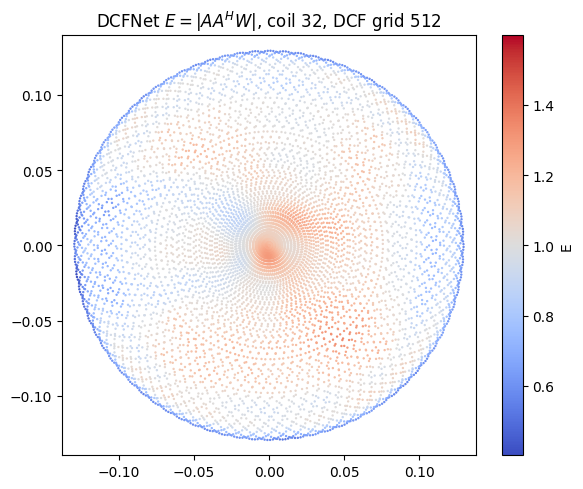

In [15]:

folder_modules = os.path.abspath('/Users/Riccardo_1/Desktop/EPFL/MRI/MR_Trajectory_Fit/dcf_generation')
if folder_modules not in sys.path:
    sys.path.append(folder_modules)

sampled_i = shape_samples_for_recon(sampled_tensor[-1], device=recon.device)
dcf, image_coil = recon.reconstruct_img_dcfnet(
    rosette_orig_recon,
    rosette_resort_recon,
    sampled_i,
    mask=None,
)

print(f"Calculated DCF shape: {dcf.shape}")
print(f"Shape of rosette resort tensor: {rosette_resort_recon.shape}")
with torch.no_grad():
    E_raw = calculate_pipe_E(
        dcf.real,
        rosette_resort_recon,
        recon.dcf_img_size,
        device=recon.device,
    )

    # Normalize over samples, not over batch.
    E_normalized_dcf = E_raw / (E_raw.mean(dim=-1, keepdim=True) + 1e-8)

    print("E_raw shape:", E_raw.shape)
    print("E_normalized shape:", E_normalized_dcf.shape)

    plot_E_colormap(E_normalized_dcf, rosette_resort_recon, title=r"DCFNet $E = |A A^H W|$, coil 32, DCF grid 512")


### dcf mirtorch E

Calculated DCF shape: torch.Size([1, 1, 8000])
Shape of rosette resort tensor: torch.Size([8000, 2])
E_raw shape: torch.Size([1, 8000])
E_normalized shape: torch.Size([1, 8000])


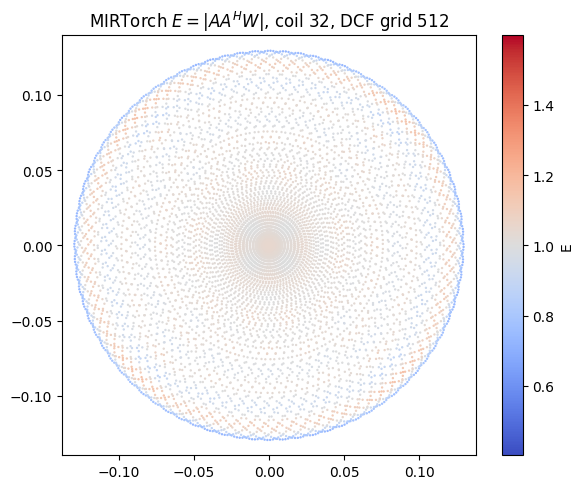

In [16]:

sampled_i = shape_samples_for_recon(sampled_tensor[-1], device=recon.device)
dcf, image_coil = recon.reconstruct_img_mirtorch(
    rosette_orig_recon,
    rosette_resort_recon,
    sampled_i,
    mask=None,
)

print(f"Calculated DCF shape: {dcf.shape}")
print(f"Shape of rosette resort tensor: {rosette_resort_recon.shape}")
with torch.no_grad():
    E_raw = calculate_pipe_E(
        dcf.real,
        rosette_resort_recon,
        recon.dcf_img_size,
        device=recon.device,
    )

    # Normalize over samples, not over batch.
    E_normalized = E_raw / (E_raw.mean(dim=-1, keepdim=True) + 1e-8)

    print("E_raw shape:", E_raw.shape)
    print("E_normalized shape:", E_normalized.shape)

    plot_E_colormap(
        E_normalized,
        rosette_resort_recon,
        title=r"MIRTorch $E = |A A^H W|$, coil 32, DCF grid 512",
        delta=np.nanmax(np.abs(E_normalized_dcf.detach().cpu().numpy() - 1.0)),
    )


## now normal rosette

In [17]:
file_name = 'meas_MID00205_FID11344_ad_edMrsi_waterRef_20260521_0535.dat'
pathTrjRef = "kspace_res50_bw2000Hz_ptls80.mat"
saving_folder = '/Users/Riccardo_1/Desktop/EPFL/MRI/MR_Trajectory_Fit/MRSI_trajs/rosette/reconstructions'

from scipy.io import loadmat

dataTrjRef = loadmat(pathTrjRef)

Kxy_smp = dataTrjRef["Kxy_smp"]   # shape: (100, 80)
Kmax = float(dataTrjRef["Kmax"].squeeze())
kxx_orig = np.real(Kxy_smp) / Kmax * kmax_traj  # shape: (100, 80)
kyy_orig = np.imag(Kxy_smp) / Kmax * kmax_traj  # shape: (100, 80)

kxx_resort = kxx_orig[:, petal_order].T # shape: (80, 100)
kyy_resort = kyy_orig[:, petal_order].T # shape: (80, 100)
kxx_orig = kxx_orig.T  # shape: (80, 100)
kyy_orig = kyy_orig.T  # shape: (80, 100)

print(f"kxx orig shape: {kxx_orig.shape}, kyy orig shape: {kyy_orig.shape}")
print(f"kxx resort shape: {kxx_resort.shape}, kyy resort shape: {kyy_resort.shape}")

rosette_orig_tensor = torch.tensor(np.stack((kxx_orig, kyy_orig), axis=-1), dtype=torch.float32)  # shape: (80, 100, 2)
rosette_resort_tensor = torch.tensor(np.stack((kxx_resort, kyy_resort), axis=-1), dtype=torch.float32)  # shape: (80, 100, 2)
rosette_orig_tensor = rosette_orig_tensor.reshape(-1, 2)
rosette_resort_tensor = rosette_resort_tensor.reshape(-1, 2)
print(f"rosette orig tensor shape: {rosette_orig_tensor.shape}")
print(f"rosette resort tensor shape: {rosette_resort_tensor.shape}")

# take points until kmax
# kxx_resort and kyy_resort have shape (80, 100)

x0, y0 = kxx_resort[0, 0], kyy_resort[0, 0] # first point of the first petal
distances = np.sqrt((kxx_resort[0, :] - x0)**2 + (kyy_resort[0, :] - y0)**2) #distances over the first petal
max_idx = np.argmax(distances)
max_dist = distances[max_idx]

print(f"Max distance is {max_dist} and the corresponding index is {max_idx}")

#take point until that point for every petal 
mask = np.zeros_like(kxx_resort, dtype=bool)
for i in range(80):
    mask[i, :max_idx+1] = True  

kxx orig shape: (80, 100), kyy orig shape: (80, 100)
kxx resort shape: (80, 100), kyy resort shape: (80, 100)
rosette orig tensor shape: torch.Size([8000, 2])
rosette resort tensor shape: torch.Size([8000, 2])
Max distance is 0.11160714285714286 and the corresponding index is 50


In [18]:
# parse the twix file
twix = twixtools.read_twix(os.path.join(main_dir, file_name))

# twix is a list of measurements:
print('\nnumber of separate scans (multi-raid):', len(twix))

# sort all 'imaging' mdbs into a k-space array
image_mdbs = [mdb for mdb in twix[-1]['mdb'] if mdb.is_image_scan()]
print(f"Number of petals: {len(image_mdbs)}") 
print(f"Shape of each petal: {image_mdbs[0].data.shape}") 

N_PETALS = 80
N_COILS = 32
N_POINTS_PER_PETAL = 100
N_REPEATS = 325
petal_order = np.r_[np.arange(0, N_PETALS, 2), np.arange(1, N_PETALS, 2)]

data_raw = np.array([mdb.data for mdb in image_mdbs])
print(f"Raw stacked shape: {data_raw.shape}") 
# Output: (80, 32, 32704)

# 42 extra points at the beginning are not valid
data_valid = data_raw[:, :, 42:]
print(f"Shape after discarding initial 42 points: {data_valid.shape}")

# We discard last points to get 32500 (100 x 325) valid points per petal
data_valid = data_valid[:, :, :32500]
print(f"Final shape: {data_valid.shape}")

data = data_valid.reshape(N_PETALS, N_COILS, N_REPEATS, N_POINTS_PER_PETAL)

# sort data
# data_resorted = data[petal_order, :, :, :]      # (80, 32, 325, 100)
data_t0 = data[:, :, 0, :]             # (80, 32, 100)
data_flat = data_t0.transpose(1, 0, 2).reshape(N_COILS, -1)

print("flat:", data_flat.shape)

sampled_tensor = torch.tensor(data_flat, dtype=torch.complex64)  # shape: (32, 8000)
print(f"sampled tensor shape: {sampled_tensor.shape}")

Software version: VD/VE (!?)

Scan  0


100%|██████████| 32.3M/32.3M [00:00<00:00, 1.86GB/s]

Scan  1


100%|██████████| 641M/641M [00:00<00:00, 1.39GB/s]



number of separate scans (multi-raid): 2
Number of petals: 80
Shape of each petal: (32, 32704)
Raw stacked shape: (80, 32, 32704)
Shape after discarding initial 42 points: (80, 32, 32662)
Final shape: (80, 32, 32500)
flat: (32, 8000)
sampled tensor shape: torch.Size([32, 8000])


In [19]:
print(f"Max k-space value in trajectory: {torch.abs(rosette_resort_tensor).max():.4f}")
new_kmax_img = float(torch.abs(rosette_resort_tensor).max())
new_resolution = int(np.round(new_kmax_img * 2 * params["FoV"]))
print(f"New reconstruction kmax_img: {new_kmax_img:.4f}")
print(f"Nominal reconstruction matrix: {new_resolution:.0f} x {new_resolution:.0f}")
new_resolution_mm = params['FoV'] / new_resolution
print(f"Nominal in-plane resolution: {new_resolution_mm:.2f} x {new_resolution_mm:.2f} mm2")

# DCF stays on the 512 x 512 grid used during DCFNet training.
# Final image reconstruction uses the trajectory-derived matrix size, e.g. 58 x 58.
recon = ImageRecon(
    params,
    kmax_img,
    dcfnet_path,
    recon_img_size=new_resolution,
    dcf_img_size=512,
    recon_kmax_img=new_kmax_img,
)

rosette_orig_recon = shape_rosette_for_recon(rosette_orig_tensor, device=recon.device)
rosette_resort_recon = shape_rosette_for_recon(rosette_resort_tensor, device=recon.device)
mask_recon = shape_mask_for_recon(mask, device=recon.device)

print("DCF image size:", recon.dcf_img_size)
print("DCF kmax_img:", recon.dcf_kmax_img)
print("Reconstruction image size:", recon.recon_img_size)
print("Reconstruction kmax_img:", recon.recon_kmax_img)
print("rosette_orig_recon:", rosette_orig_recon.shape)
print("rosette_resort_recon:", rosette_resort_recon.shape)
print("mask_recon:", mask_recon.shape)

Max k-space value in trajectory: 0.1116
New reconstruction kmax_img: 0.1116
Nominal reconstruction matrix: 50 x 50
Nominal in-plane resolution: 4.48 x 4.48 mm2
DCF image size: 512
DCF kmax_img: 1.1428571428571428
Reconstruction image size: 50
Reconstruction kmax_img: 0.1116071417927742
rosette_orig_recon: torch.Size([8000, 2])
rosette_resort_recon: torch.Size([8000, 2])
mask_recon: torch.Size([8000])


In [20]:
images_coils = []
for i in range(N_COILS):
    sampled_i = shape_samples_for_recon(sampled_tensor[i], device=recon.device)
    _, image_coil = recon.reconstruct_img_dcfnet(
        rosette_orig_recon,
        rosette_resort_recon,
        sampled_i,
        mask=mask_recon,
    )
    images_coils.append(image_coil.detach().cpu().numpy())

images_coils = np.array(images_coils)
image_rss_dcfnet_masked_rosette = np.sqrt(np.sum(np.abs(images_coils)**2, axis=0))

images_coils = []
for i in range(N_COILS):
    sampled_i = shape_samples_for_recon(sampled_tensor[i], device=recon.device)
    _, image_coil = recon.reconstruct_img_dcfnet(
        rosette_orig_recon,
        rosette_resort_recon,
        sampled_i,
        mask=None,
    )
    images_coils.append(image_coil.detach().cpu().numpy())

images_coils = np.array(images_coils)
image_rss_dcfnet_rosette = np.sqrt(np.sum(np.abs(images_coils)**2, axis=0))

images_coils = []
for i in range(N_COILS):
    sampled_i = shape_samples_for_recon(sampled_tensor[i], device=recon.device)
    _, image_coil = recon.reconstruct_img_mirtorch(
        rosette_orig_recon,
        rosette_resort_recon,
        sampled_i,
        mask=mask_recon,
    )
    images_coils.append(image_coil.detach().cpu().numpy())

images_coils = np.array(images_coils)
image_rss_mirtorch_masked_rosette = np.sqrt(np.sum(np.abs(images_coils)**2, axis=0))

images_coils = []
for i in range(N_COILS):
    sampled_i = shape_samples_for_recon(sampled_tensor[i], device=recon.device)
    _, image_coil = recon.reconstruct_img_mirtorch(
        rosette_orig_recon,
        rosette_resort_recon,
        sampled_i,
        mask=None,
    )
    images_coils.append(image_coil.detach().cpu().numpy())

images_coils = np.array(images_coils)
image_rss_mirtorch_rosette = np.sqrt(np.sum(np.abs(images_coils)**2, axis=0))

print(f"Max and min pixel value in DCFNet reconstruction: {image_rss_dcfnet_masked_rosette.max()}, {image_rss_dcfnet_masked_rosette.min()}")
print(f"Max and min pixel value in DCFNet reconstruction (unmasked): {image_rss_dcfnet_rosette.max()}, {image_rss_dcfnet_rosette.min()}")
print(f"Max and min pixel value in MIRTorch reconstruction: {image_rss_mirtorch_masked_rosette.max()}, {image_rss_mirtorch_masked_rosette.min()}")
print(f"Max and min pixel value in MIRTorch reconstruction (unmasked): {image_rss_mirtorch_rosette.max()}, {image_rss_mirtorch_rosette.min()}")

print("Output image shape:", image_rss_dcfnet_rosette.shape)
i_max = max(image_rss_dcfnet_masked_rosette.max(), image_rss_mirtorch_masked_rosette.max(), image_rss_dcfnet_rosette.max(), image_rss_mirtorch_rosette.max())

Setting kbnufft operator for DCF normalization with 8000 points and image size (512, 512)
Setting kbnufft operator for masked recon with 4080 points and image size (50, 50)
Setting kbnufft operator for DCF normalization with 8000 points and image size (512, 512)
Setting kbnufft operator for masked recon with 4080 points and image size (50, 50)
Setting kbnufft operator for DCF normalization with 8000 points and image size (512, 512)
Setting kbnufft operator for masked recon with 4080 points and image size (50, 50)
Setting kbnufft operator for DCF normalization with 8000 points and image size (512, 512)
Setting kbnufft operator for masked recon with 4080 points and image size (50, 50)
Setting kbnufft operator for DCF normalization with 8000 points and image size (512, 512)
Setting kbnufft operator for masked recon with 4080 points and image size (50, 50)
Setting kbnufft operator for DCF normalization with 8000 points and image size (512, 512)
Setting kbnufft operator for masked recon wit

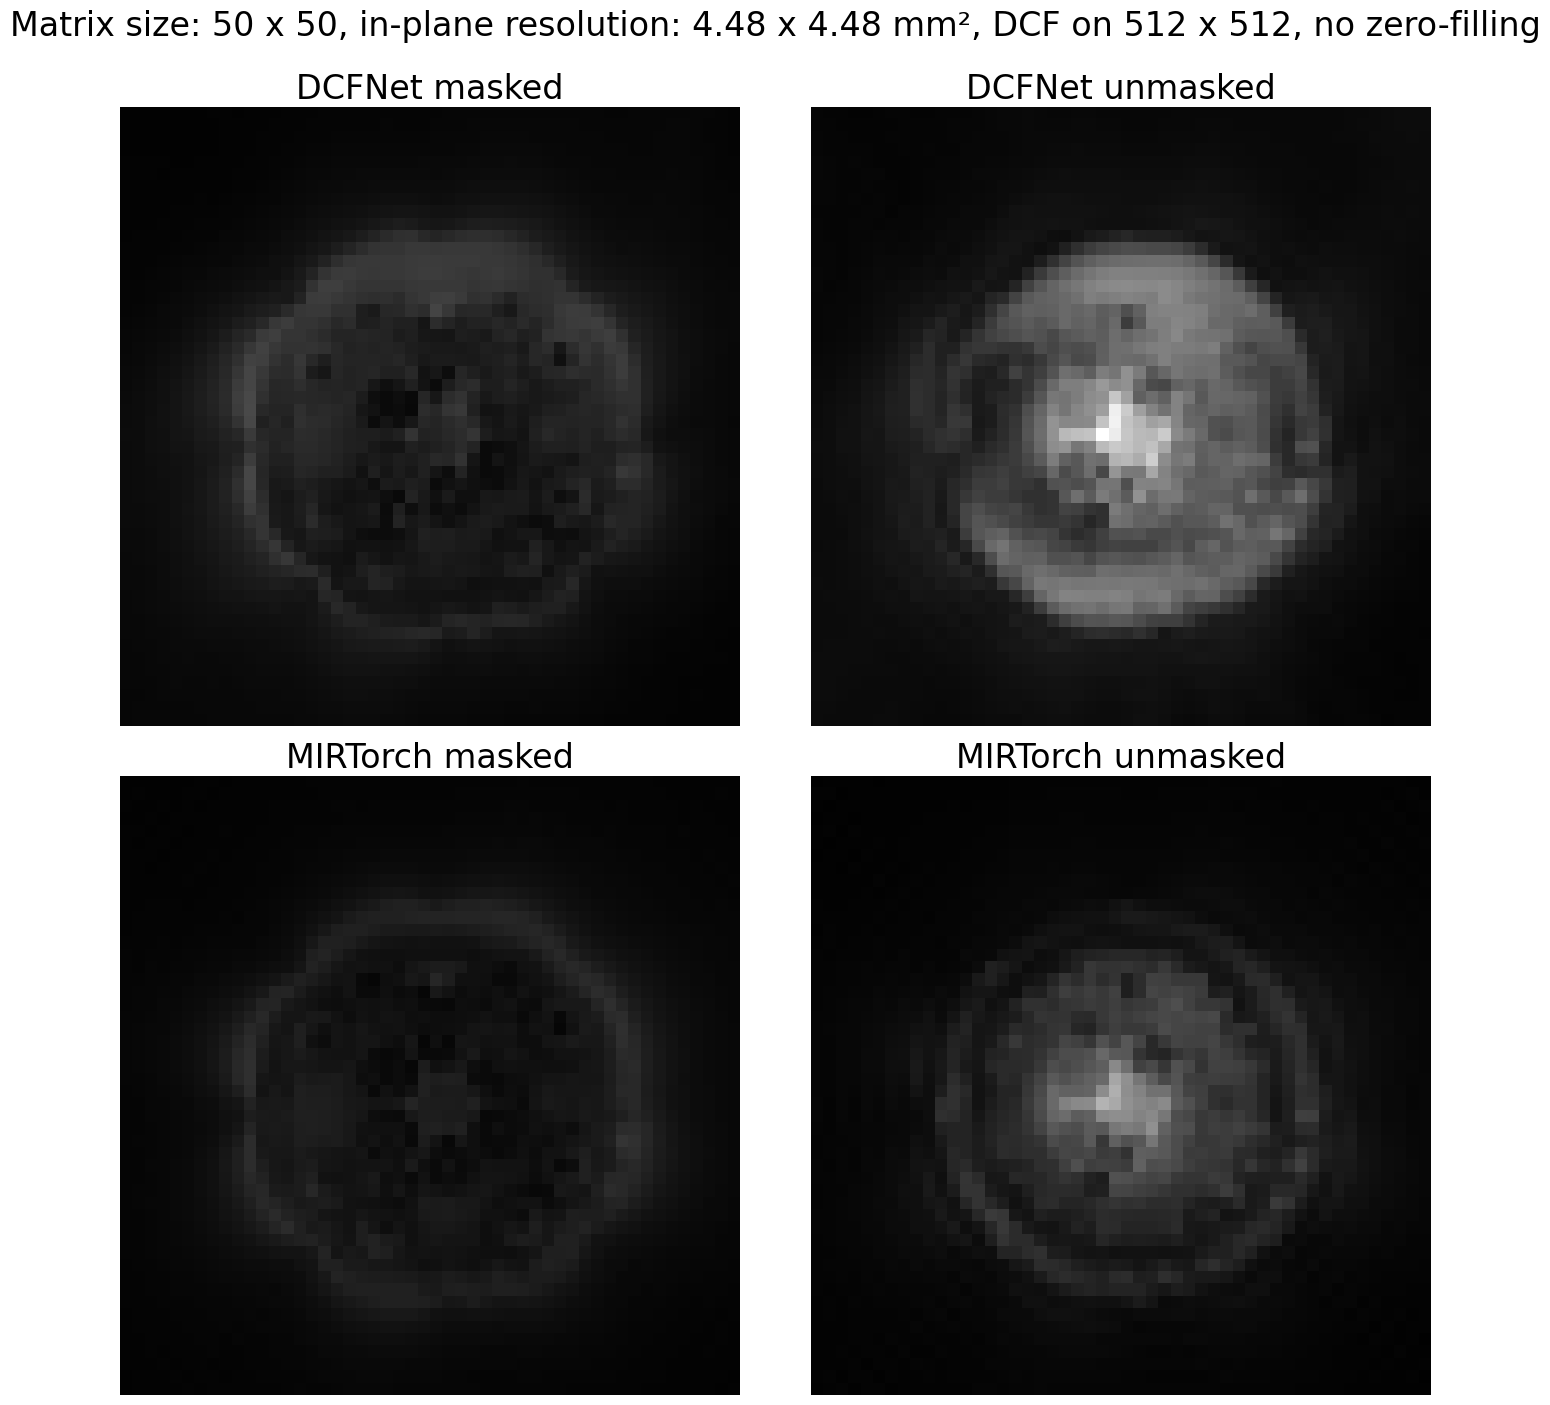

In [21]:
titles = [
    "DCFNet masked",
    "DCFNet unmasked",
    "MIRTorch masked",
    "MIRTorch unmasked",
]

images = [
    image_rss_dcfnet_masked_rosette,
    image_rss_dcfnet_rosette,
    image_rss_mirtorch_masked_rosette,
    image_rss_mirtorch_rosette,
]

plt.figure(figsize=(14, 14))

for idx, (img, title) in enumerate(zip(images, titles), start=1):
    plt.subplot(2, 2, idx)
    plt.imshow(np.abs(img), cmap="gray", vmin=0, vmax=i_max)
    plt.title(title, fontsize=24)
    plt.axis("off")

plt.suptitle(
    f"Matrix size: {new_resolution} x {new_resolution}, "
    f"in-plane resolution: {new_resolution_mm:.2f} x {new_resolution_mm:.2f} mm², "
    f"DCF on 512 x 512, no zero-filling",
    fontsize=24,
    y=1
)

plt.tight_layout()
plt.show()

### image for abstract

Using:
  rosette DCFNet   -> image_rss_dcfnet_masked_rosette
  rosette MIRTorch -> image_rss_mirtorch_masked_rosette
  optim.  DCFNet   -> image_rss_dcfnet_masked
  optim.  MIRTorch -> image_rss_mirtorch_masked
Common image scaling: vmax = 1.8118655134458095e-05 from
first max: 1.6341760783689097e-05
second max: 1.1537620594026521e-05
third max: 1.8118655134458095e-05
fourth max: 1.5436469766427763e-05


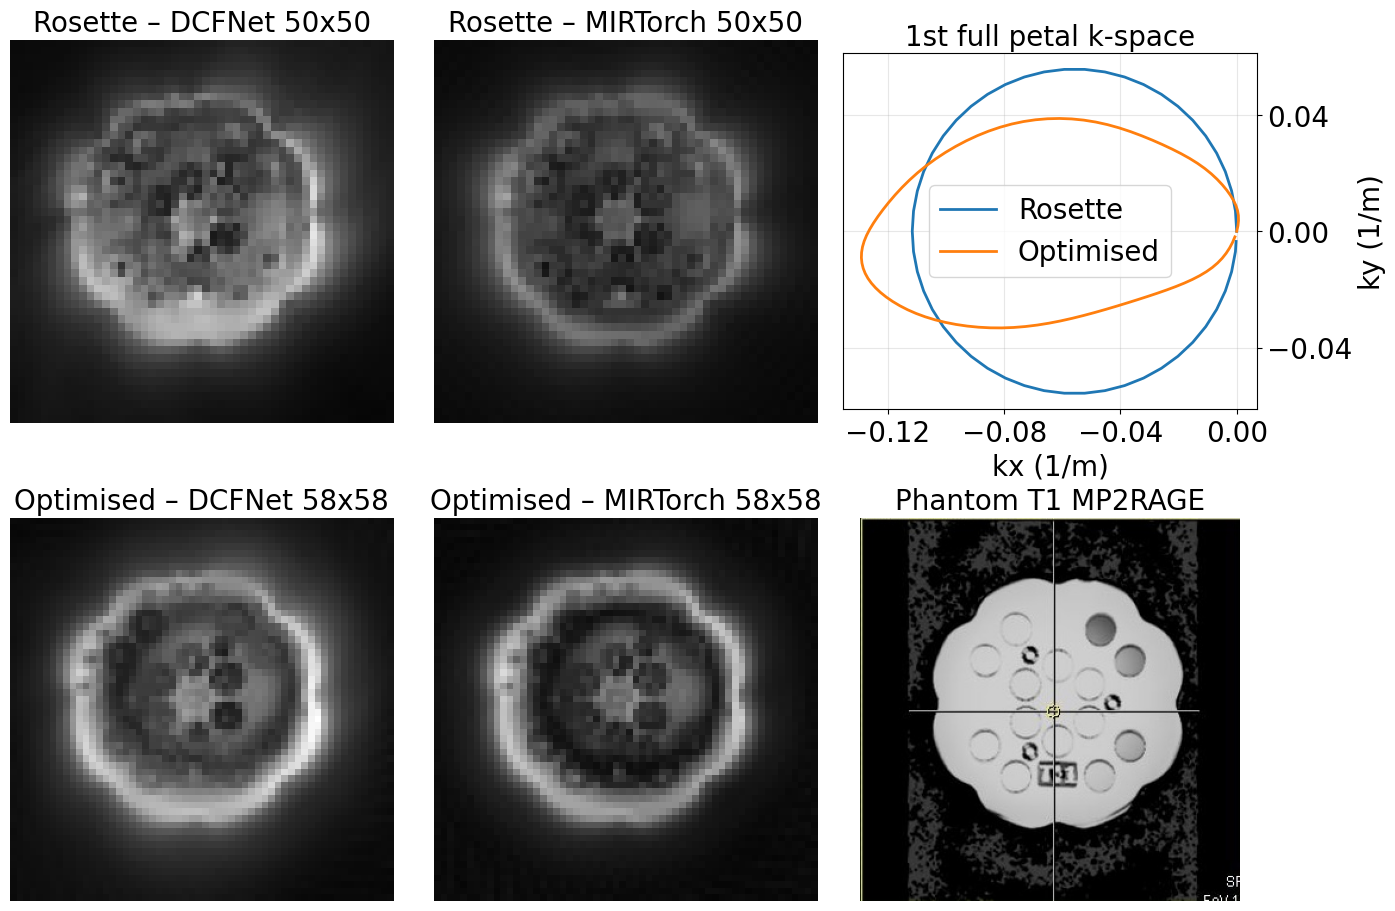

In [27]:
import matplotlib.image as mpimg
from matplotlib.ticker import MaxNLocator

# ----------------------------
# Helper to pick variables automatically
# ----------------------------
def pick_var(candidates):
    for name in candidates:
        if name in globals():
            return globals()[name], name
    raise NameError(f"None of these variables were found: {candidates}")

# ---- reconstruction images ----
# Edit the candidate lists below only if your variable names are different.
img_rosette_dcfnet, name_rosette_dcfnet = pick_var([
    "image_rss_dcfnet_masked_rosette"
])

img_rosette_mirtorch, name_rosette_mirtorch = pick_var([
    "image_rss_mirtorch_masked_rosette"
])

img_opt_dcfnet, name_opt_dcfnet = pick_var([
    "image_rss_dcfnet_masked"
])

img_opt_mirtorch, name_opt_mirtorch = pick_var([
    "image_rss_mirtorch_masked"
])

print("Using:")
print("  rosette DCFNet   ->", name_rosette_dcfnet)
print("  rosette MIRTorch ->", name_rosette_mirtorch)
print("  optim.  DCFNet   ->", name_opt_dcfnet)
print("  optim.  MIRTorch ->", name_opt_mirtorch)

# ---- trajectory for the inset plot (first full petal) ----
kx_rosette, _ = pick_var([
    "kxx_orig",
    "kx_orig",
    "kxx_rosette",
])
ky_rosette, _ = pick_var([
    "kyy_orig",
    "ky_orig",
    "kyy_rosette",
])

kx_opt, _ = pick_var([
    "kxx_optim"
])
ky_opt, _ = pick_var([
    "kyy_optim"
])

x_ros = np.asarray(kx_rosette[20])
y_ros = np.asarray(ky_rosette[20])
x_opt = np.asarray(kx_opt[0])
y_opt = np.asarray(ky_opt[0])

# ---- phantom image ----
phantom_path = os.path.join(folder_modules, "MRSI_trajs/data/4Riccardo/slicePoscut.JPG") if "folder_modules" in globals() else "MRSI_trajs/data/4Riccardo/slicePoscut.JPG"
if not os.path.exists(phantom_path):
    phantom_path = "MRSI_trajs/data/4Riccardo/slicePoscut.JPG"
phantom = mpimg.imread(phantom_path)

# ---- common image scaling ----
vmax = max(
    np.abs(img_rosette_dcfnet).max(),
    np.abs(img_rosette_mirtorch).max(),
    np.abs(img_opt_dcfnet).max(),
    np.abs(img_opt_mirtorch).max(),
)

print(f"Common image scaling: vmax = {vmax} from")
print(f"first max: {np.abs(img_rosette_dcfnet).max()}") 
print(f"second max: {np.abs(img_rosette_mirtorch).max()}") 
print(f"third max: {np.abs(img_opt_dcfnet).max()}") 
print(f"fourth max: {np.abs(img_opt_mirtorch).max()}")

# ----------------------------
# Figure
# ----------------------------
fig, axes = plt.subplots(
    2, 3,
    figsize=(14, 9),
    gridspec_kw={"width_ratios": [1, 1, 1]},
    constrained_layout=True
)

# Row 1: rosette
axes[0, 0].imshow(np.rot90(np.abs(img_rosette_dcfnet), 2), cmap="gray", vmin=0, vmax=vmax)
axes[0, 0].set_title("Rosette – DCFNet 50x50", fontsize=20)
axes[0, 0].axis("off")

axes[0, 1].imshow(np.rot90(np.abs(img_rosette_mirtorch), 2), cmap="gray", vmin=0, vmax=vmax)
axes[0, 1].set_title("Rosette – MIRTorch 50x50", fontsize=20)
axes[0, 1].axis("off")

# Row 2: optimised
axes[1, 0].imshow(np.rot90(np.abs(img_opt_dcfnet), 2), cmap="gray", vmin=0, vmax=vmax)
axes[1, 0].set_title("Optimised – DCFNet 58x58", fontsize=20)
axes[1, 0].axis("off")

axes[1, 1].imshow(np.rot90(np.abs(img_opt_mirtorch), 2), cmap="gray", vmin=0, vmax=vmax)
axes[1, 1].set_title("Optimised – MIRTorch 58x58", fontsize=20)
axes[1, 1].axis("off")

# Last column: phantom (square in both rows)
axes[1, 2].imshow(phantom, cmap="gray" if phantom.ndim == 2 else None)
axes[1, 2].set_title("Phantom T1 MP2RAGE", fontsize=20)
axes[1, 2].axis("off")
axes[1, 2].set_box_aspect(1)  # make width = height


# Optional: keep all image axes square too
for r in range(2):
    for c in range(2):
        axes[r, c].set_box_aspect(1)


axes[0,2].plot(x_ros, y_ros, lw=2, label="Rosette")
axes[0,2].plot(x_opt, y_opt, lw=2, label="Optimised")

xmin = min(x_ros.min(), x_opt.min())
xmax = max(x_ros.max(), x_opt.max())
ymin = min(y_ros.min(), y_opt.min())
ymax = max(y_ros.max(), y_opt.max())

dx = xmax - xmin
dy = ymax - ymin
pad_x = 0.05 * dx if dx > 0 else 0.1
pad_y = 0.05 * dy if dy > 0 else 0.1

axes[0,2].set_xlim(xmin - pad_x, xmax + pad_x)
axes[0,2].set_ylim(ymin - pad_y, ymax + pad_y)
axes[0,2].yaxis.tick_right()
axes[0,2].yaxis.set_label_position("right")
axes[0,2].set_aspect("equal")
axes[0,2].xaxis.set_major_locator(MaxNLocator(nbins=4))
axes[0,2].yaxis.set_major_locator(MaxNLocator(nbins=4))
axes[0,2].tick_params(axis="both", which="major", labelsize=20)
axes[0,2].set_title("1st full petal k-space", fontsize=20)
axes[0,2].grid(True, alpha=0.3)
axes[0,2].legend(fontsize=20, loc="best")
axes[0,2].set_xlabel("kx (1/m)", fontsize=20)
axes[0,2].set_ylabel("ky (1/m)", fontsize=20)

plt.show()